In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [5]:
data = pd.read_csv("GDAXI.csv").iloc[::-1].reset_index(drop=True)
data.head()

,Date,Open,High,Low,Close
0,01/03/00,6961.72,6750.76,6750.76,6750.76
1,01/04/00,6747.24,6586.95,6586.95,6586.95
2,01/05/00,6585.85,6502.07,6502.07,6502.07
3,01/06/00,6501.45,6474.92,6474.92,6474.92
4,01/07/00,6489.94,6780.96,6780.96,6780.96


In [6]:
X = np.log(data[" Close"]).diff().dropna()
L = -100*X

In [7]:
def sample_mean_excess(X,v:np.array):
    n = len(v)
    l = np.zeros(shape=(n))
    j = 0
    for i in v:
        l[j] = sum(X[X>i]-i)/len(X[X>i])
        j+=1
    return l

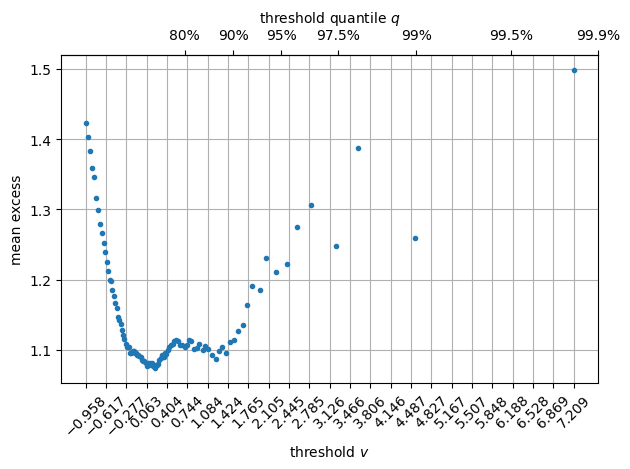

In [8]:
qu = 0.2
qv = 0.999
q= np.linspace(qu,qv,100)
v = np.quantile(L,q)

import matplotlib.ticker as mticker

fig, ax1 = plt.subplots()

ax1.plot(v, sample_mean_excess(L, v), '.')
ax1.set_xlabel('threshold $v$')
ax1.set_ylabel('mean excess')

# interpolation maps
def v_to_q(x):
    return np.interp(x, v, q)

def q_to_v(x):
    return np.interp(x, q, v)

sec = ax1.secondary_xaxis('top', functions=(v_to_q, q_to_v))
sec.set_xlabel('threshold quantile $q$')

# choose readable top-axis ticks
q_ticks = np.array([0.80, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999])
q_ticks = q_ticks[(q_ticks >= q.min()) & (q_ticks <= q.max())]

sec.set_xticks(q_ticks)
sec.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{100*x:g}%")
)

sec.tick_params(axis='x', rotation=0, pad=6)
ax1.set_xticks(np.linspace(v.min(), v.max(), 25))
ax1.tick_params(axis='x', rotation=45)
plt.grid()



plt.tight_layout()
plt.show()


threshold=1.200, xi_hat=0.063404, slope=0.067697, intercept=1.041088, R²=0.817610
threshold=1.300, xi_hat=0.061374, slope=0.065387, intercept=1.050517, R²=0.805513
threshold=1.500, xi_hat=0.057122, slope=0.060583, intercept=1.071164, R²=0.787145
threshold=1.600, xi_hat=0.053236, slope=0.056229, intercept=1.090830, R²=0.775359
threshold=2.200, xi_hat=0.046881, slope=0.049187, intercept=1.124672, R²=0.692850


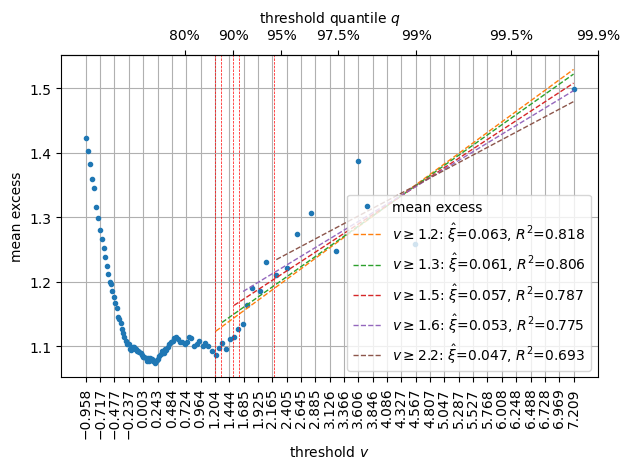

In [9]:
thresholds = np.array([1.2,1.3,1.5,1.6,2.2])

y = sample_mean_excess(L, v)

fig, ax1 = plt.subplots()

ax1.plot(v, y, '.', label='mean excess')
ax1.set_xlabel('threshold $v$')
ax1.set_ylabel('mean excess')

def v_to_q(x):
    return np.interp(x, v, q)

def q_to_v(x):
    return np.interp(x, q, v)

sec = ax1.secondary_xaxis('top', functions=(v_to_q, q_to_v))
sec.set_xlabel('threshold quantile $q$')

q_ticks = np.array([0.80, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999])
q_ticks = q_ticks[(q_ticks >= q.min()) & (q_ticks <= q.max())]

sec.set_xticks(q_ticks)
sec.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{100*x:g}%")
)
sec.tick_params(axis='x', rotation=0, pad=6)

ax1.set_xticks(np.linspace(v.min(), v.max(), 35))
ax1.tick_params(axis='x', rotation=90)

for t in thresholds:
    ax1.axvline(t, color="red", lw=0.5, linestyle='--')

    mask = (v >= t) & np.isfinite(v) & np.isfinite(y)

    x_fit = v[mask]
    y_fit = y[mask]

    a, b = np.polyfit(x_fit, y_fit, 1)
    y_hat = a * x_fit + b

    xi_hat = a / (1 + a)

    ss_res = np.sum((y_fit - y_hat)**2)
    ss_tot = np.sum((y_fit - y_fit.mean())**2)
    r2 = 1 - ss_res / ss_tot

    ax1.plot(
        x_fit,
        y_hat,
        linewidth=1,
        linestyle='--',
        label=fr"$v\geq {t}$: $\hat\xi$={xi_hat:.3f}, $R^2$={r2:.3f}"
    )

    print(
        f"threshold={t:.3f}, "
        f"xi_hat={xi_hat:.6f}, "
        f"slope={a:.6f}, "
        f"intercept={b:.6f}, "
        f"R²={r2:.6f}"
    )

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

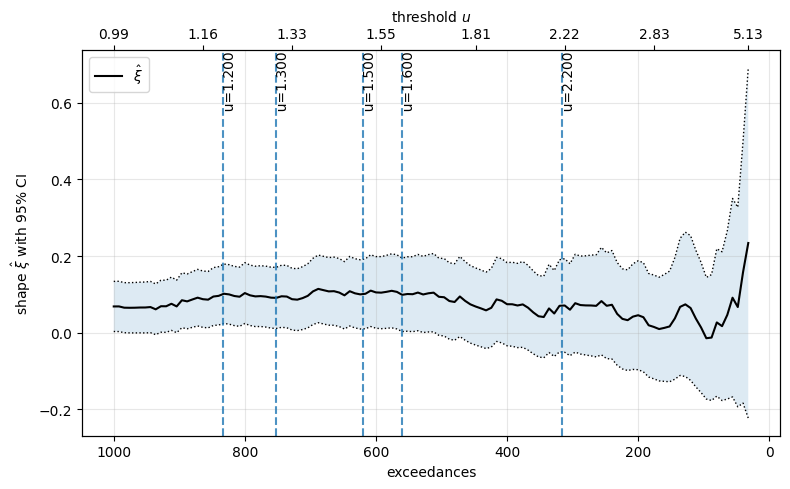

In [10]:
# ------------------------------------------------------------------
# SHAPE STABILITY PLOT: xi vs threshold with likelihood-based CIs
# ------------------------------------------------------------------
from scipy.optimize import minimize
from scipy.stats import genpareto
import numpy as np
import matplotlib.pyplot as plt

z = np.asarray(L)
z = z[np.isfinite(z)]
zs = np.sort(z)
N = len(zs)


def gpd_nll(p, y):
    xi_, beta_ = p
    
    if beta_ <= 0:
        return 1e10
    
    if abs(xi_) < 1e-8:
        return len(y) * np.log(beta_) + y.sum() / beta_
    
    t = 1 + xi_ * y / beta_
    
    if np.any(t <= 0):
        return 1e10
    
    return len(y) * np.log(beta_) + (1 + 1 / xi_) * np.log(t).sum()

ks = np.arange(min(1000, N - 5), 25, -8)

used_ks, us, xis, ses = [], [], [], []

for k in ks:
    u = zs[N - k]
    y = zs[zs > u] - u
    
    if len(y) < 10:
        continue
    
    xi0, _, beta0 = genpareto.fit(y, floc=0)
    r = minimize(gpd_nll, [xi0, beta0], args=(y,), method="Nelder-Mead")
    
    if not r.success:
        continue
    
    p0 = r.x
    h = 1e-4
    H = np.zeros((2, 2))
    E = np.eye(2)
    
    for i in range(2):
        for j in range(2):
            a = gpd_nll(p0 + h * E[i] + h * E[j], y)
            b = gpd_nll(p0 + h * E[i] - h * E[j], y)
            c = gpd_nll(p0 - h * E[i] + h * E[j], y)
            d = gpd_nll(p0 - h * E[i] - h * E[j], y)
            H[i, j] = (a - b - c + d) / (4 * h**2)
    
    try:
        cov = np.linalg.inv(H)
        se_xi = np.sqrt(max(cov[0, 0], 0))
    except Exception:
        se_xi = np.nan
    
    used_ks.append(k)
    us.append(u)
    xis.append(p0[0])
    ses.append(se_xi)

used_ks = np.asarray(used_ks)
us = np.asarray(us)
xis = np.asarray(xis)
ses = np.asarray(ses)

lo = xis - 1.96 * ses
hi = xis + 1.96 * ses

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(used_ks, xis, 'k-', lw=1.5, label=r'$\hat\xi$')
ax.plot(used_ks, lo, 'k:', lw=1)
ax.plot(used_ks, hi, 'k:', lw=1)
ax.fill_between(used_ks, lo, hi, alpha=0.15)

ax.invert_xaxis()
ax.set_xlabel('exceedances')
ax.set_ylabel(r'shape $\hat\xi$ with 95% CI')
ax.grid(alpha=0.3)

# mark your selected thresholds
for t in thresholds:
    k_t = np.sum(zs > t)
    
    if used_ks.min() <= k_t <= used_ks.max():
        ax.axvline(k_t, linestyle='--', alpha=0.8)
        ax.text(
            k_t,
            ax.get_ylim()[1],
            f'  u={t:.3f}',
            rotation=90,
            va='top',
            ha='left'
        )

# top axis: threshold values corresponding to exceedance counts
axt = ax.twiny()
axt.set_xlim(ax.get_xlim())

idx = np.linspace(0, len(used_ks) - 1, 8).astype(int)
axt.set_xticks(used_ks[idx])
axt.set_xticklabels([f'{us[i]:.2f}' for i in idx])
axt.set_xlabel('threshold $u$')

ax.legend()
plt.tight_layout()
plt.show()

In [11]:
def g(x):
    return stats.multivariate_normal.cdf(x,
                                         mean=np.array([0,0]),
                                         cov=np.array(([1,-0.4],[-0.4,1]))
                                         )

x = np.array([0,0])
x1 = np.array([-100,0])
x2 = np.array([0,-100])
x3 = np.array([0,100])

print(g(x),g(x1),g(x2),g(x3))

0.18450505978277268 0.0 0.0 0.5


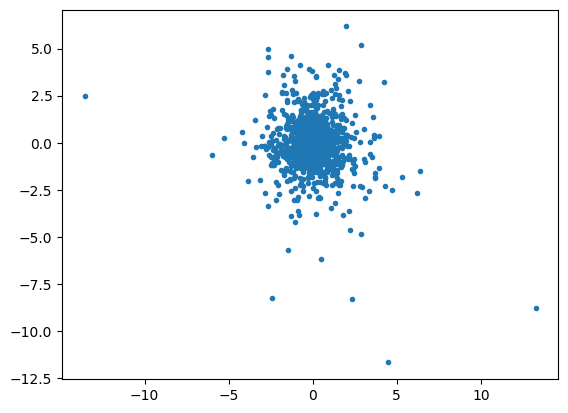

In [12]:
t = stats.multivariate_t(loc=np.array([0,0]),shape=np.array([[1,0],[0,1]]),df=4)
x = t.rvs(size=1000)
plt.plot(x[:,0],x[:,1],'.')
plt.show()

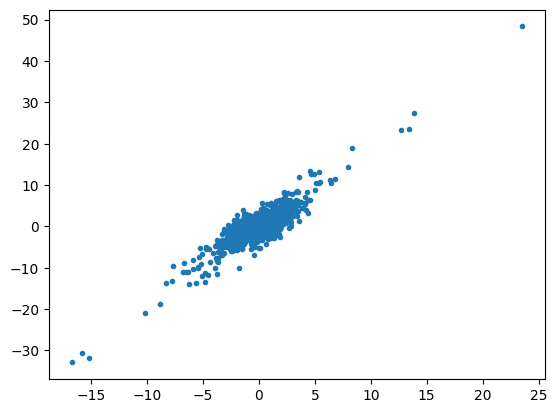

In [13]:
z = np.random.standard_t(2,1000)
x1 = np.random.normal(0,1,1000)-z
x2 = np.random.normal(0,1,1000)-2*z
plt.plot(x1,x2,'.')
plt.show()

In [14]:
import numpy as np
from scipy.stats import norm, rankdata, kendalltau

n = len(x1)
u1, u2 = rankdata(x1)/(n+1), rankdata(x2)/(n+1)   # pseudo-observations
z1, z2 = norm.ppf(u1), norm.ppf(u2)               # normal scores

rho_mle = np.corrcoef(z1, z2)[0, 1]               # pseudo-MLE of rho
rho_tau = np.sin(np.pi/2 * kendalltau(x1, x2).statistic)  # tau-inversion alternative

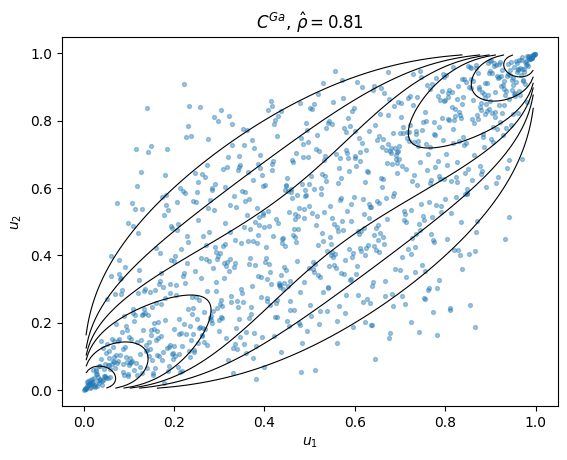

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

g = np.linspace(0.005, 0.995, 200)
U, V = np.meshgrid(g, g)
Z1, Z2 = norm.ppf(U), norm.ppf(V)
mvn = multivariate_normal([0, 0], [[1, rho_mle], [rho_mle, 1]])
c = mvn.pdf(np.dstack([Z1, Z2])) / (norm.pdf(Z1) * norm.pdf(Z2))  # copula density

plt.scatter(u1, u2, s=8, alpha=0.4)                # pseudo-observations
plt.contour(U, V, c, levels=[0.5, 1, 1.5, 2, 3, 5], colors="k", linewidths=0.8)
plt.xlabel(r"$u_1$"); plt.ylabel(r"$u_2$")
plt.title(rf"$C^{{Ga}}$, $\hat\rho={rho_mle:.2f}$")
plt.show()

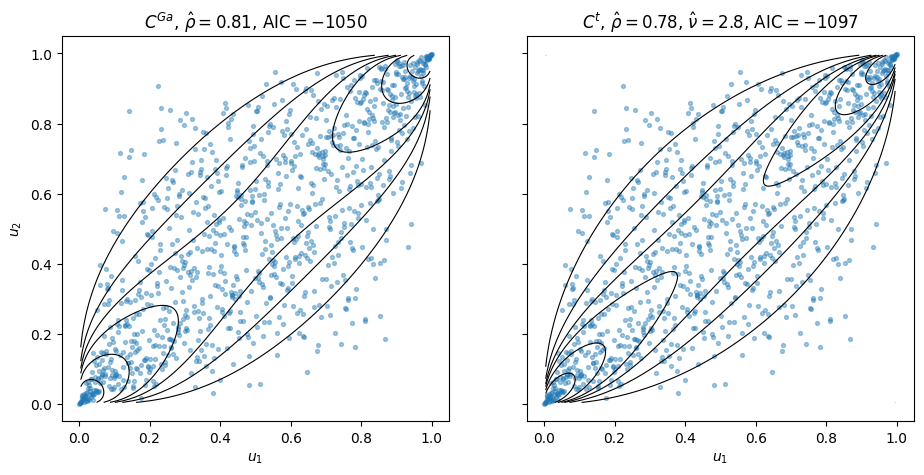

In [16]:
from scipy.stats import t as tdist, multivariate_t
from scipy.optimize import minimize_scalar

# t copula: tau-inversion for rho (same relation as Gaussian), profile likelihood for nu
rho_t = np.sin(np.pi/2 * kendalltau(x1, x2).statistic)

def negll_t(nu):
    q1, q2 = tdist.ppf(u1, nu), tdist.ppf(u2, nu)
    mvt = multivariate_t([0, 0], [[1, rho_t], [rho_t, 1]], df=nu)
    return -(mvt.logpdf(np.column_stack([q1, q2]))
             - tdist.logpdf(q1, nu) - tdist.logpdf(q2, nu)).sum()

nu_hat = minimize_scalar(negll_t, bounds=(2.01, 60), method="bounded").x
ll_t = -negll_t(nu_hat)
ll_g = (mvn.logpdf(np.column_stack([z1, z2]))
        - norm.logpdf(z1) - norm.logpdf(z2)).sum()
aic_g, aic_t = 2*1 - 2*ll_g, 2*2 - 2*ll_t

# densities on the grid (Gaussian c from before)
Q1, Q2 = tdist.ppf(U, nu_hat), tdist.ppf(V, nu_hat)
mvt = multivariate_t([0, 0], [[1, rho_t], [rho_t, 1]], df=nu_hat)
c_t = np.exp(mvt.logpdf(np.dstack([Q1, Q2]))
             - tdist.logpdf(Q1, nu_hat) - tdist.logpdf(Q2, nu_hat))

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for a, dens, ttl in [
    (ax[0], c,   rf"$C^{{Ga}}$, $\hat\rho={rho_mle:.2f}$, AIC$={aic_g:.0f}$"),
    (ax[1], c_t, rf"$C^t$, $\hat\rho={rho_t:.2f}$, $\hat\nu={nu_hat:.1f}$, AIC$={aic_t:.0f}$"),
]:
    a.scatter(u1, u2, s=8, alpha=0.4)
    a.contour(U, V, dens, levels=[0.5, 1, 1.5, 2, 3, 5], colors="k", linewidths=0.8)
    a.set_xlabel(r"$u_1$")
ax[0].set_ylabel(r"$u_2$"); ax[0].set_title(ttl) if False else None
ax[0].set_title(rf"$C^{{Ga}}$, $\hat\rho={rho_mle:.2f}$, AIC$={aic_g:.0f}$")
ax[1].set_title(rf"$C^t$, $\hat\rho={rho_t:.2f}$, $\hat\nu={nu_hat:.1f}$, AIC$={aic_t:.0f}$")
plt.show()

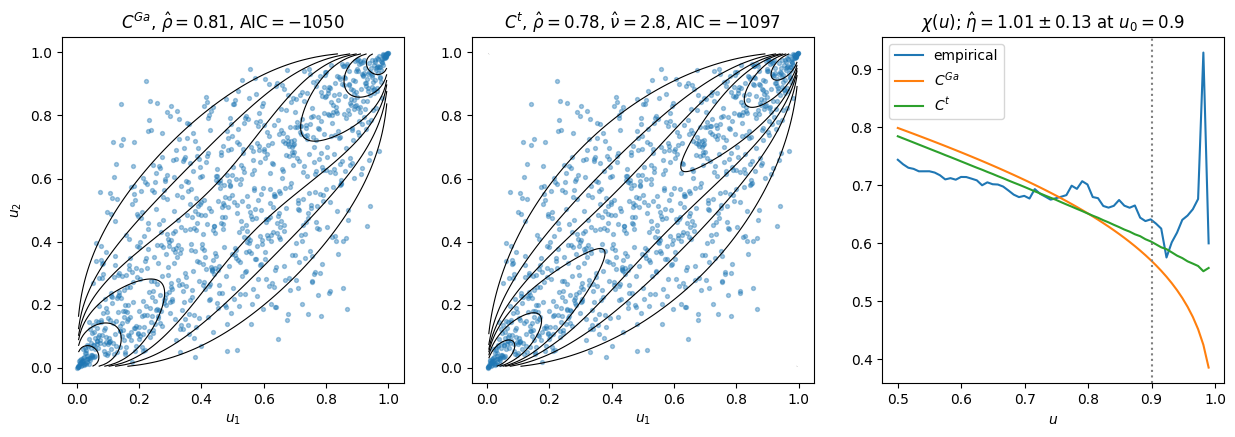

In [17]:
u0 = 0.9
us = np.linspace(0.5, 0.99, 60)
chi_emp = np.array([((u1 > u) & (u2 > u)).mean() for u in us])/(1 - us)
chi_g = np.array([1 - 2*u + mvn.cdf(norm.ppf([u, u])) for u in us])/(1 - us)
chi_t = np.array([1 - 2*u + mvt.cdf(tdist.ppf([u, u], nu_hat)) for u in us])/(1 - us)

T = np.minimum(1/(1 - u1), 1/(1 - u2))     # unit Pareto structure variable
exc = T[T > 1/(1 - u0)]                    # exceedances above u0
eta_hat = np.log(exc*(1 - u0)).mean()      # Hill estimator of eta
se = eta_hat/np.sqrt(len(exc))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, dens, ttl in [
    (ax[0], c,   rf"$C^{{Ga}}$, $\hat\rho={rho_mle:.2f}$, AIC$={aic_g:.0f}$"),
    (ax[1], c_t, rf"$C^t$, $\hat\rho={rho_t:.2f}$, $\hat\nu={nu_hat:.1f}$, AIC$={aic_t:.0f}$"),
]:
    a.scatter(u1, u2, s=8, alpha=0.4)
    a.contour(U, V, dens, levels=[0.5, 1, 1.5, 2, 3, 5], colors="k", linewidths=0.8)
    a.set_xlabel(r"$u_1$"); a.set_title(ttl)
ax[0].set_ylabel(r"$u_2$")

ax[2].plot(us, chi_emp, label="empirical")
ax[2].plot(us, chi_g, label=r"$C^{Ga}$")
ax[2].plot(us, chi_t, label=r"$C^t$")
ax[2].axvline(u0, ls=":", c="gray")
ax[2].set_xlabel(r"$u$")
ax[2].set_title(rf"$\chi(u)$; $\hat\eta={eta_hat:.2f}\pm{se:.2f}$ at $u_0={u0}$")
ax[2].legend()
plt.show()

In [18]:
P = np.array([[1, 0.7], [0.7, 1]])
A = np.linalg.cholesky(P)
Z = np.random.randn(1000, 2)
X = Z@A
U = stats.norm.cdf(X)
U.shape

(1000, 2)

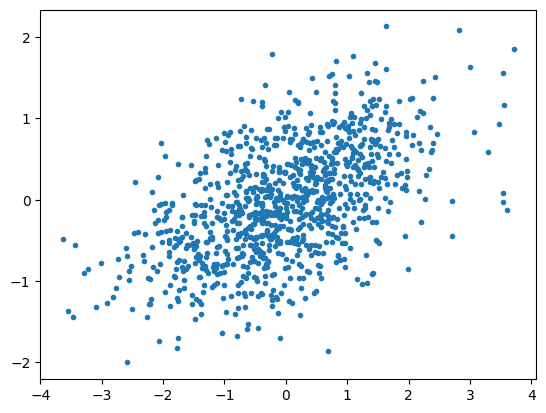

In [19]:
plt.plot(X[:,0],X[:,1],'.')
plt.show()

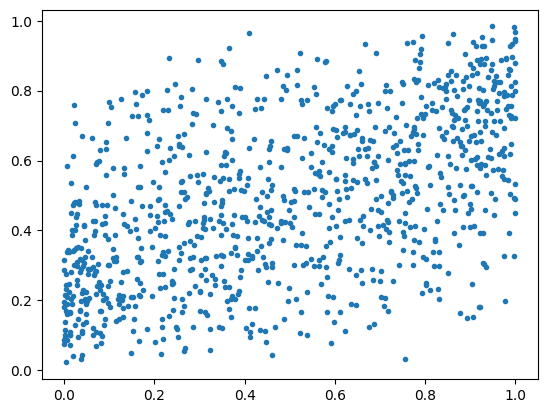

In [20]:
plt.plot(U[:,0],U[:,1],'.')
plt.show()

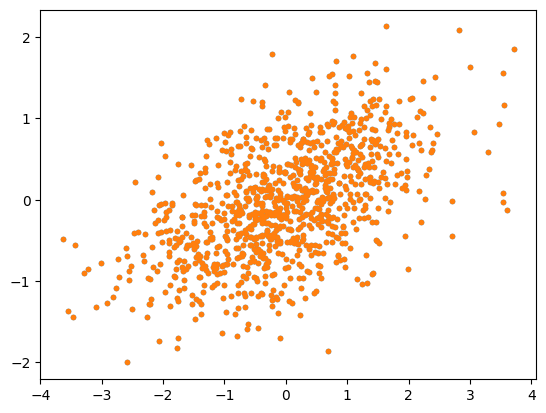

In [21]:
X_tr = stats.norm.ppf(U)
plt.plot(X_tr[:,0],X_tr[:,1],'.')
plt.plot(X[:,0],X[:,1],'.')
plt.show()

In [22]:
np.allclose(X_tr, X)          # True
np.max(np.abs(X_tr - X))      # near machine precision

1.163513729807164e-13

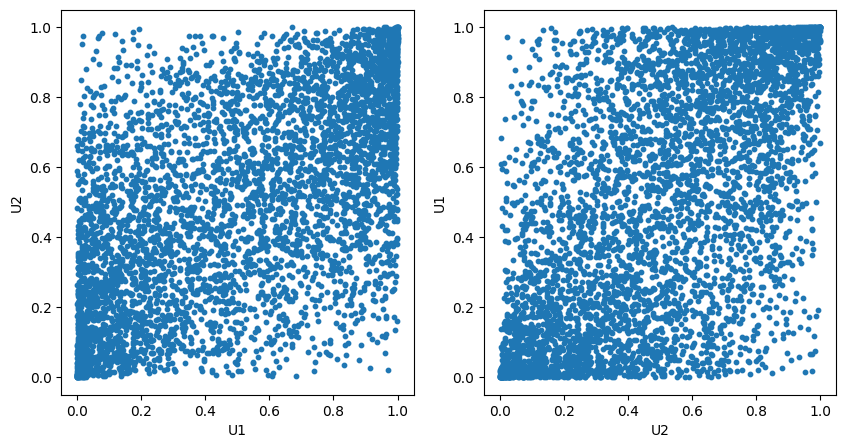

In [42]:
rho, nu = 0.9, 20
P = np.array([[2, rho], [rho, 1]])

X = stats.multivariate_t(
    loc=np.zeros(2),
    shape=P,
    df=nu
).rvs(size=5000)

U = stats.t.cdf(X, df=nu)   # Student-t copula sample
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(U[:, 0], U[:, 1], s=10)
plt.xlabel("U1")
plt.ylabel("U2")
plt.subplot(1,2,2)
plt.scatter(U[:, 1], U[:, 0], s=10)
plt.xlabel("U2")
plt.ylabel("U1")
plt.show()

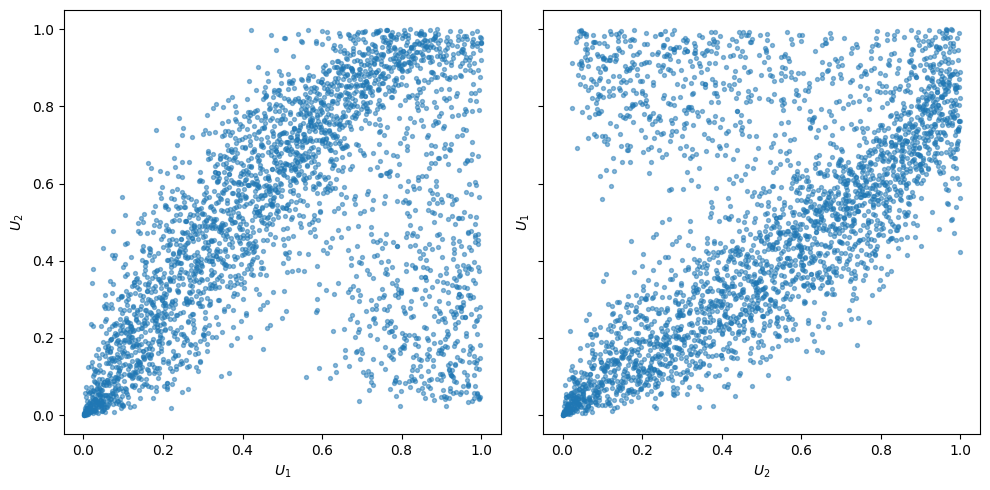

0.43966666666666665 0.3443333333333333


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skewnorm, rankdata

def sample_skew_normal_mixture(n=3000, seed=1):
    rng = np.random.default_rng(seed)
    component = rng.choice(2, size=n, p=[0.7, 0.3])
    X = np.empty((n, 2))

    parameters = [
        {"rho": 0.90, "a": (8, -2),  "loc": (-1.0, 0.2),  "scale": (1.0, 0.8)},
        {"rho": -0.20, "a": (-6, 10), "loc": (1.8, -1.2), "scale": (0.7, 1.4)}
    ]

    for k, p in enumerate(parameters):
        idx = component == k
        R = np.array([[1, p["rho"]], [p["rho"], 1]])

        Z = rng.multivariate_normal([0, 0], R, size=idx.sum())
        Q = norm.cdf(Z)

        X[idx, 0] = p["loc"][0] + p["scale"][0] * skewnorm.ppf(Q[:, 0], p["a"][0])
        X[idx, 1] = p["loc"][1] + p["scale"][1] * skewnorm.ppf(Q[:, 1], p["a"][1])

    # Empirical probability-integral transforms
    U = np.column_stack([
        (rankdata(X[:, j]) - 0.5) / n
        for j in range(2)
    ])

    return U


U = sample_skew_normal_mixture()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

axes[0].scatter(U[:, 0], U[:, 1], s=8, alpha=0.5)
axes[0].set_xlabel(r"$U_1$")
axes[0].set_ylabel(r"$U_2$")

axes[1].scatter(U[:, 1], U[:, 0], s=8, alpha=0.5)
axes[1].set_xlabel(r"$U_2$")
axes[1].set_ylabel(r"$U_1$")

plt.tight_layout()
plt.show()

# Numerical check
u, v = 0.45, 0.75
C_uv = np.mean((U[:, 0] <= u) & (U[:, 1] <= v))
C_vu = np.mean((U[:, 0] <= v) & (U[:, 1] <= u))

print(C_uv, C_vu)

In [ ]:
# z = np.random.normal(0,1,size=(10_000_000,10))
# sigma1=1; sigma2=2
# s1 = (np.exp(sigma1*z))
# s2 = (np.exp(sigma2*z))
# rho = stats.pearsonr(s1,s2)


# # print(np.cov(s1,s2)[0,1]/(np.std(s1,ddof=1)*np.std(s2,ddof=1)))
# # plt.plot(s1,s2,'.')
# # plt.show()

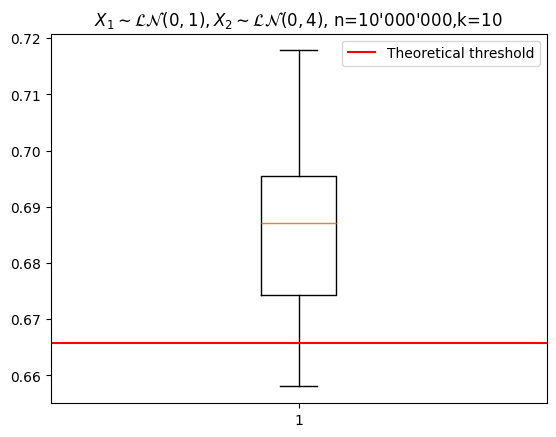

In [ ]:
# plt.boxplot(rho.correlation)
# plt.title(fr"$X_1\sim\mathcal{{LN}}(0,{sigma1**2}),X_2\sim\mathcal{{LN}}(0,{sigma2**2})$, n=10'000'000,k=10")
# plt.axhline((np.exp(sigma1*sigma2)-1)/np.sqrt((np.exp(sigma1**2)-1)*(np.exp(sigma2**2)-1)),color="red",label="Theoretical threshold")
# plt.legend()
# plt.show()

In [ ]:
# stats.kendalltau(s1,s2)

SignificanceResult(statistic=1.0, pvalue=0.0)

In [ ]:
# rho = np.array([
#     stats.spearmanr(s1[:, j], s2[:, j]).statistic
#     for j in range(s1.shape[1])
# ])

KeyboardInterrupt: 

In [ ]:
# rho

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

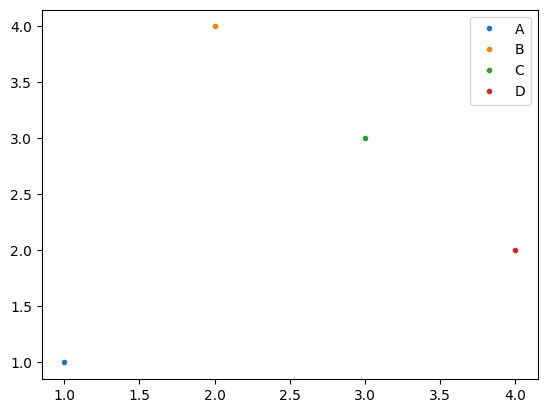

In [ ]:
plt.plot(1,1,'.',label="A")
plt.plot(2,4,'.',label="B")
plt.plot(3,3,'.',label="C")
plt.plot(4,2,'.',label="D")
plt.legend()
plt.show()

In [ ]:
# import requests

# url = "https://epicbet.com/s/sport-odds/public/activeOdds.getPreMatchByMarketIds?input=%5B138761995%2C138761996%2C138761997%2C138761998%2C138761999%2C138762005%2C138762007%2C138762010%2C138762012%2C138762013%2C138762014%2C138762020%2C138762021%2C138762023%2C138762024%2C138762026%2C138762032%2C138762033%2C138762034%2C138762036%2C138762037%2C138762041%2C138762043%2C138762044%2C138762045%2C138762046%2C138762052%2C138762053%2C138762055%2C138762056%2C138762062%2C138762068%2C138762070%2C138762071%2C138762073%2C138762074%2C138762076%2C138762077%2C138762078%2C138762079%2C138762081%2C138762082%2C138762084%2C138762085%2C138762087%2C138762088%2C138762090%2C138762091%2C138762092%2C138762093%2C138762094%2C138762098%2C138762099%2C138762100%2C138762102%2C138762118%2C138762121%2C138762125%2C138762126%2C138762127%2C138762128%2C138762129%2C138762130%2C138762138%2C138762139%2C138762140%2C138762141%2C138762145%2C138762147%2C138762148%2C138762151%2C138762153%2C138762157%2C138762158%2C138762160%2C138762161%2C138762166%2C138762167%2C138762168%2C138762169%2C138762178%2C138762179%2C138762181%2C138762183%2C138762184%2C138762185%2C138762186%2C138762187%2C138762188%2C138762189%2C138762190%2C138762191%2C138762192%2C138762193%2C138762201%2C138762203%2C138762205%2C138762210%2C138762230%2C138762233%2C138762236%2C138762238%2C138762240%2C138762244%2C138762246%2C138762272%2C138762274%2C138762276%2C138762278%2C138762280%2C138762281%2C138762307%2C138762310%2C138762312%2C138762316%2C138762318%2C138762320%2C138762322%2C138762323%2C138762324%2C138762325%2C138762327%2C138762328%2C138762333%2C138762334%2C138762335%2C138762337%2C138762338%2C138762339%2C138762340%2C138762341%2C138762342%2C138762343%2C138762344%2C138762346%2C138762351%2C138762352%2C138762354%2C138762356%2C138762357%2C138762358%2C138762363%2C138762364%2C138762370%2C138762371%2C138762373%2C138762374%2C138762375%2C138762376%2C138762377%2C138762381%2C138762382%2C138762384%2C138762389%2C138762390%2C138762392%2C138762393%2C138762394%2C138762395%2C138762396%2C138762397%2C138762398%2C138762399%2C138762400%2C138762401%2C138762402%2C138762403%2C138762404%2C138762406%2C138762408%2C138764516%2C138766661%2C138871908%2C139022284%2C139022285%2C139022286%2C139022287%2C139022288%2C139022289%2C139022290%2C139022291%2C139022292%2C139022293%2C139022308%2C139022309%2C139022310%2C139022311%2C139022312%2C139022313%2C139022314%2C139022315%2C139022316%2C139022317%2C139022322%2C139022323%2C139022324%2C139022325%2C139022326%2C139022327%2C139022328%2C139022329%2C139022330%2C139022334%2C139022339%2C139022340%2C139022341%2C139022342%2C139022343%2C139022344%2C139022345%2C139022346%2C139022348%2C139022350%2C139022352%2C139022353%2C139022355%2C139022361%2C139022363%2C139022364%2C139022365%2C139022366%2C139022367%2C139022369%2C139022370%2C139022373%2C139022381%2C139022384%2C139022385%2C139022386%2C139022387%2C139022388%2C139022389%2C139022390%2C139022391%2C139022396%2C139022397%2C139022398%2C139022407%2C139022408%2C139022409%2C139022415%2C139022418%2C139022421%2C139022423%2C139022425%2C139022429%2C139022430%2C139022431%2C139022432%2C139022433%2C139022434%2C139022437%2C139022438%2C139022439%2C139022447%2C139022448%2C139022449%2C139022454%2C139022455%2C139022459%2C139022460%2C139022466%2C139022473%2C139022474%2C139022475%2C139022476%2C139022477%2C139022478%2C139022479%2C139022480%2C139022481%2C139022482%2C139022498%2C139022499%2C139022510%2C139022511%2C139022519%2C139022520%2C139022522%2C139022525%2C139022526%2C139022527%2C139022528%2C139022531%2C139022535%2C139022537%2C139022538%2C139022541%2C139022543%2C139022544%2C139022560%2C139022561%2C139022562%2C139022563%2C139022567%2C139022568%2C139022569%2C139022572%2C139022576%2C139022580%2C139022583%2C139022590%2C139022593%2C139022594%2C139022598%2C139022599%2C139022600%2C139022601%2C139022602%2C139022603%2C139022609%2C139022610%2C139022611%2C139022612%2C139022613%2C139022614%2C139022615%2C139022616%2C139022617%2C139022618%2C139022621%2C139022622%2C139022623%2C139022624%2C139022625%2C139022626%2C139022627%2C139022628%2C139022629%2C139022630%2C139022631%2C139022634%2C139022635%2C139022636%2C139022637%2C139022638%2C139022639%2C139022640%2C139022641%2C139022642%2C139022643%2C139022644%2C139022645%2C139022646%2C139022647%2C139022648%2C139022649%2C139022650%2C139022652%2C139022653%2C139022655%2C139022656%2C139022659%2C139022660%2C139022663%2C139022664%2C139022668%2C139022669%2C139022670%2C139022671%2C139022672%2C139022673%2C139022674%2C139022686%2C139022687%2C139022692%2C139022693%2C139022694%2C139022695%2C139022696%2C139022697%2C139022698%2C139022699%2C139022700%2C139022703%2C139022704%2C139022705%2C139022716%2C139022717%2C139022727%2C139022728%2C139022736%2C139022744%2C139022745%2C139022746%2C139022747%2C139022748%2C139022749%2C139022750%2C139022751%2C139022752%2C139022753%2C139022766%2C139022767%2C139022768%2C139022769%2C139022770%2C139022771%2C139022772%2C139022773%2C139022780%2C139022781%2C139022782%2C139022783%2C139022784%2C139022785%2C139022800%2C139022808%2C139022809%2C139022833%2C139022837%2C139022838%2C139022839%2C139022840%2C139022843%2C139022845%2C139022846%2C139022848%2C139022849%2C139022850%2C139022851%2C139022852%2C139022853%2C139022854%2C139022855%2C139022856%2C139022858%2C139022862%2C139022871%2C139022872%2C139022873%2C139022874%2C139022882%2C139022891%2C139022892%2C139022894%2C139022897%2C139022900%2C139022901%2C139022902%2C139022903%2C139022908%2C139022909%2C139022916%2C139022917%2C139022918%2C139022921%2C139022922%2C139022925%2C139022926%2C139022927%2C139022929%2C139022930%2C139022931%2C139022932%2C139022933%2C139022936%2C139022937%2C139022938%2C139022939%2C139022940%2C139022965%2C139022966%2C139022967%2C139022968%2C139022976%2C139022977%2C139022994%2C139022995%2C139022996%2C139022998%2C139022999%2C139023000%2C139023001%2C139023010%2C139023011%2C139023012%2C139023013%2C139023014%2C139023019%2C139023020%2C139023021%2C139023022%2C139023023%2C139023024%2C139023025%2C139023028%2C139023029%2C139023030%2C139023033%2C139023034%2C139023035%2C139031635%2C139031636%2C139031640%2C139031655%2C139031659%2C139031661%2C139031662%2C139031667%2C139031672%2C140168708%2C140187687%5D"

# headers = {
#     "authority": "epicbet.com",
#     "accept": "*/*",
#     "accept-language": "en-GB,en;q=0.9,is;q=0.8,en-US;q=0.7,de;q=0.6",
#     "cache-control": "no-cache",
#     "pragma": "no-cache",
#     "referer": "https://epicbet.com/is/ithrottir?matchId=1680529&sportId=1&categoryId=-1&isFromFeaturedEvents=true",
#     "sec-ch-ua": '"Not;A=Brand";v="8", "Chromium";v="150", "Google Chrome";v="150"',
#     "sec-ch-ua-mobile": "?0",
#     "sec-ch-ua-platform": '"Windows"',
#     "sec-fetch-dest": "empty",
#     "sec-fetch-mode": "cors",
#     "sec-fetch-site": "same-origin",
#     "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36",
# }

# # Important: Add your cf_clearance cookie here
# cookies = {
#     "cf_clearance": "UzbsxYwarWkL72cnTXZ6Kg6FeTcuS0CymhFN21D3jgE-1783491654-1.2.1.1-wXo3JVz8f5AHX2tnXY96_g2TIKo6aKjfJsrdy__jofUvr5hVha2EH5LZ4ltoFPq6RKtPr6.joHM6GkmMfg.7.mKhJ_7lnY4FvrvJrphuuuiZzLRyGDIGVl0Yvl4tQYXR3n9bEQIPpbGBRH1he2eVMsOaWxlLBk7qtnB78AleE7mbHrUJhM6.6H0GWTGVnjBVMqhdGiugf_rymqh5bmUK54KZSle6DF2GB3XfiUnjG0KND4e2sv_YKY3LNZq5.TaXR2YzTpmrMaP3LEPW2eqjNUQ_qZWoQ5XiDskg1EvfKpIGP70RheVQnNz5CgTnrQsVQPkY9ep78jAqNmOljXkjdQiNvLmZWGsIAc.FbMIum3qCpuc.hcFrOPIaoOiMi5LF.AF.Pr.qJx5TVB.fA_tqqSltBnVrUGkykqICwD_Kzzh.zykZ4gubd9OMXuaytGrl",
#     # You can add more cookies if needed
# }

# response = requests.get(url, headers=headers, cookies=cookies, timeout=30)

# print("Status Code:", response.status_code)

# if response.status_code == 200:
#     print("✅ Success!")
#     print("Response size:", len(response.text), "bytes")
#     # Save full response
#     with open("response.json", "w", encoding="utf-8") as f:
#         f.write(response.text)
#     print("Full response saved to response.json")
# else:
#     print("❌ Still blocked or error")
#     print(response.text[:800])  # Show beginning of error page

Status Code: 200
✅ Success!
Response size: 231501 bytes
Full response saved to response.json


In [46]:
Z = np.random.normal(0,1,1000)
print(np.mean(np.abs(z)*z))
print(2/np.sqrt(np.pi*2))

0.00024148878690258193
0.7978845608028654


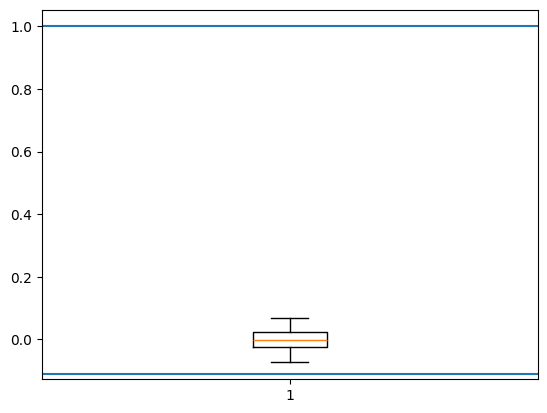

In [197]:
p = 0.9
x = np.random.binomial(1,p,size=(1000,100))
y = np.random.binomial(1,p,size=(1000,100))

plt.boxplot(stats.pearsonr(x,y).correlation)
plt.axhline(1,label="Theoretical upper limit")
plt.axhline((p/(p-1))*(p<=1/2)+((p-1)/(p))*(p>1/2),label="Theoretical lower limit")

plt.show()

In [578]:
U = np.random.uniform(0,1,100000)
print(np.mean(np.log(1-U)*np.log(U))-1)
print(1-np.pi**2/6)

-0.644731123113963
-0.6449340668482264


In [580]:
r1 = np.array([1,2,3,4,5])
r2 = np.array([1,4,2,5,3])
stats.pearsonr(r1,r2)

PearsonRResult(statistic=0.5, pvalue=0.391002218955771)

In [ ]:
r3 = r2**2
stats.pearsonr(r1,r3)



PearsonRResult(statistic=0.40879371260483044, pvalue=0.4943914848100612)